In [1]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.explore as explore
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(explore)
importlib.reload(plot)

<module 'utilities.plot' from '/Users/xuechenkan/potts_model_test/ms1/../utilities/plot.py'>

In [2]:
import sys
import importlib
sys.path.append('../')  # Adjust the path as needed

import utilities.functions as functions
import utilities.explore as explore
import utilities.plot as plot

# Reload the module to reflect the changes
importlib.reload(functions)
importlib.reload(explore)
importlib.reload(plot)
IN_seq_path = 'IN/data/in.reduce4.seq'
PR_seq_path = 'PR/data/pr.exper.reduce4.seq'    
RT_seq_path = 'RT/data/rt.reduce4.seq'

IN_all_seq = functions.read_seq('IN/data/in.reduce4.seq')
PR_all_seq = functions.read_seq('PR/data/pr.exper.reduce4.seq')
RT_all_seq = functions.read_seq('RT/data/rt.reduce4.seq')

IN_consensus = 'IN/data/in.consensus.reduce4.seq'
with open(IN_consensus, 'r') as f:
    IN_consensus_seq = f.read().strip()
# print("IN consensus sequence:", IN_consensus_seq)
PR_consensus = 'PR/data/pr.consensus.reduce4.seq'
with open(PR_consensus, 'r') as f:
    PR_consensus_seq = f.read().strip()
RT_consensus = 'RT/data/rt.consensus.reduce4.seq'
with open(RT_consensus, 'r') as f:
    RT_consensus_seq = f.read().strip()

# print(IN_consensus_seq)
    
IN_redux = functions.get_redu_dict('IN/data/in.reduce4.redux',1)
PR_redux = functions.get_redu_dict('PR/data/pr.reduce4.redux',0)
RT_redux = functions.get_redu_dict('RT/data/rt.reduce4.redux',0)

IN_J = functions.load_J_dict('IN/data/J.npy',1,263)
PR_J = functions.load_J_dict('PR/data/J_PR.npy',1,99)
RT_J = functions.load_J_dict('RT/data/J_RT.npy',39,226)

IN_all_seq_unreduced = functions.read_seq('IN/data/in.fullseq')
PR_all_seq_unreduced = functions.read_seq('PR/data/pr.exper.fullseq')
RT_all_seq_unreduced = functions.read_seq('RT/data/rt.fullseq')

In [3]:
# # print(functions.calculate_e(IN_all_seq[100], IN_J,1,263))
# explore.draw_heatmap(IN_consensus_seq,IN_all_seq[:1000], IN_J, 1, 263)

C140D-D148B
len seq with mutaiton 221


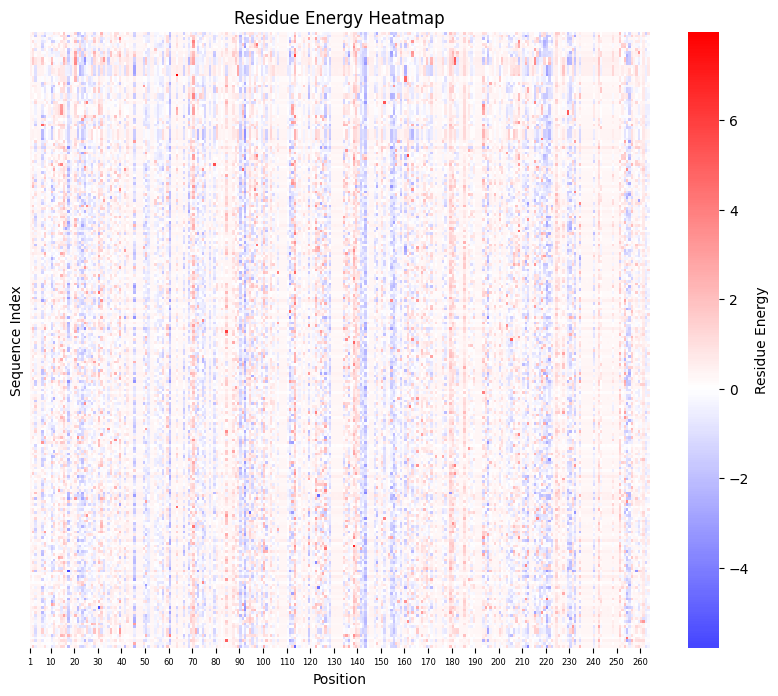

In [4]:
IN_pair = 'G140S-Q148H'
# IN_pair = 'Y143C-S230R'
# IN_pair = 'G140A-Q148K'
# IN_pair = 'G140S-Q148R'
# IN_pair = 'G140S-Q148K'

# IN_pair = 'Y143R-N155H'
pair1, pair2 = functions.split_pairs(IN_pair)
p1_reduced = functions.unreduced_to_reduced(IN_redux, pair1)
p2_reduced = functions.unreduced_to_reduced(IN_redux, pair2)

pos1 = functions.split_pair(pair1)[1]
pos2 = functions.split_pair(pair2)[1]

p12_reduced = p1_reduced+'-'+p2_reduced


re_mutation = functions.unreduced_to_reduced_pair(IN_redux, IN_pair)
print(re_mutation)

m1,m2 = functions.split_pairs(re_mutation)
# print(m1,m2)
_,pos1,mt1 = functions.split_pair(m1)
# print (mt1)
_,pos2,mt2 = functions.split_pair(m2)
seq_with_mutation = []
for seq in IN_all_seq:
    if seq[pos1 - 1] == mt1 and seq[pos2 - 1] == mt2:
        seq_with_mutation.append(seq)
    
print('len seq with mutaiton', len(seq_with_mutation))
explore.draw_heatmap(IN_consensus_seq,seq_with_mutation, IN_J, 1, 263)


len seq without mutaiton 971


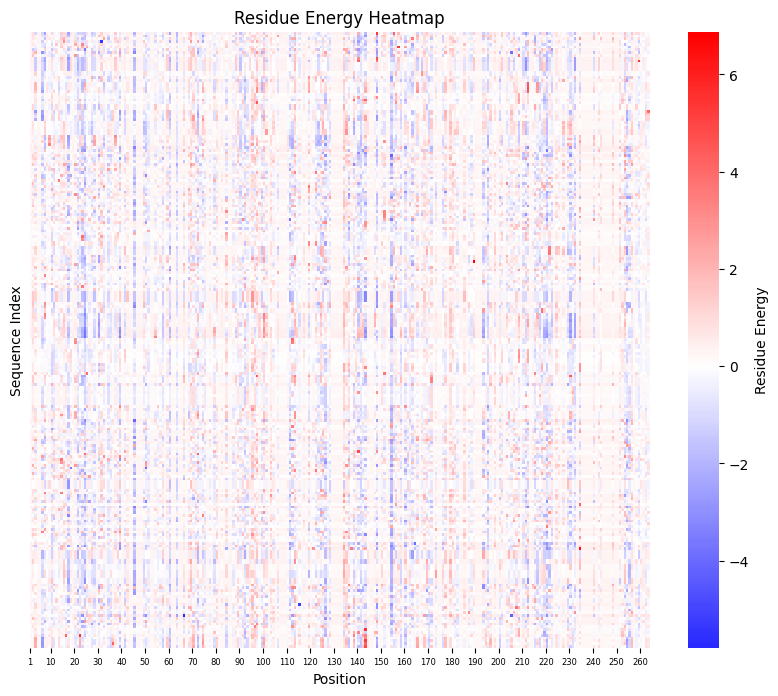

In [5]:

seq_without_mutation = []
for seq in IN_all_seq:
    if seq[pos1 - 1] != mt1 and seq[pos2 - 1] != mt2:
        seq_without_mutation.append(seq)
    
print('len seq without mutaiton', len(seq_without_mutation))
explore.draw_heatmap(IN_consensus_seq,seq_without_mutation[:221], IN_J, 1, 263)


Top 5 deciding positions: [126  92 143 113  95]


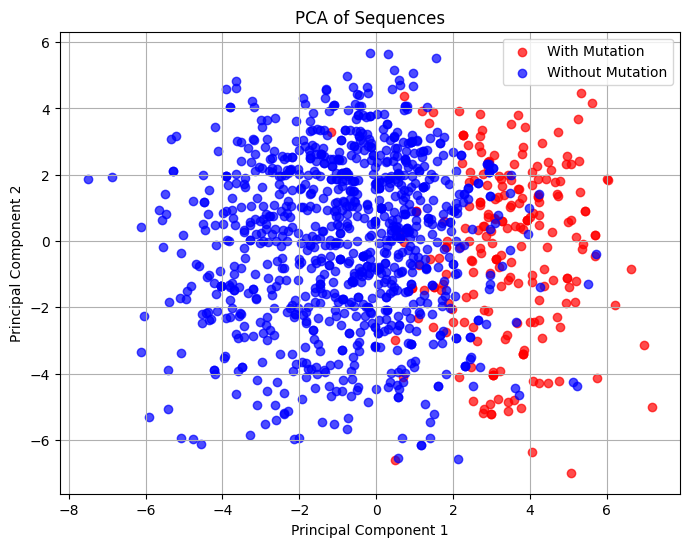

In [6]:
from sklearn.decomposition import PCA
import numpy as np

# Define a mapping from characters to integers
unique_chars = set(''.join(seq_with_mutation + seq_without_mutation))
char_to_int = {char: idx for idx, char in enumerate(unique_chars)}

# Use the residue energy (e) at each position as the value
def calculate_residue_energy(sequence, J_matrix):
    energy = []
    for i, residue in enumerate(sequence):
        e = 0
        for j, other_residue in enumerate(sequence):
            if (i + 1, j + 1, residue, other_residue) in J_matrix:
                e += J_matrix[(i + 1, j + 1, residue, other_residue)]
        energy.append(e)
    return energy

# Convert sequences to numerical format using residue energy
def encode_sequences(sequences, J_matrix):
    encoded = []
    for seq in sequences:
        encoded.append(calculate_residue_energy(seq, J_matrix))
    return np.array(encoded)

# Encode sequences with and without mutation using residue energy
encoded_with_mutation = encode_sequences(seq_with_mutation, IN_J)
encoded_without_mutation = encode_sequences(seq_without_mutation, IN_J)

# Combine both sets of sequences for PCA
combined_sequences = np.vstack((encoded_with_mutation, encoded_without_mutation))

# Run PCA
pca = PCA(n_components=5)
pca.fit(combined_sequences)

# Get the top 5 deciding positions based on explained variance
top_deciding_positions = np.argsort(-np.abs(pca.components_).sum(axis=0))[:5]
print("Top 5 deciding positions:", top_deciding_positions + 1)  # Add 1 to convert to 1-based indexing

import matplotlib.pyplot as plt

# Project the sequences onto the first two principal components
pca_transformed = pca.transform(combined_sequences)

# Separate the transformed data for sequences with and without mutation
pca_with_mutation = pca_transformed[:len(encoded_with_mutation)]
pca_without_mutation = pca_transformed[len(encoded_with_mutation):]

# Plot the PCA results
plt.figure(figsize=(8, 6))
plt.scatter(pca_with_mutation[:, 0], pca_with_mutation[:, 1], color='red', label='With Mutation', alpha=0.7)
plt.scatter(pca_without_mutation[:, 0], pca_without_mutation[:, 1], color='blue', label='Without Mutation', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Sequences')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# # Get indexes of sequences with and without mutations
# indexes_with_mutation = [IN_all_seq.index(seq) for seq in seq_with_mutation]
# indexes_without_mutation = [IN_all_seq.index(seq) for seq in seq_without_mutation]

# # Get unreduced sequences using the indexes
# unreduced_with_mutation = [IN_all_seq_unreduced[idx] for idx in indexes_with_mutation]
# unreduced_without_mutation = [IN_all_seq_unreduced[idx] for idx in indexes_without_mutation]

# # Write sequences with mutations to a FASTA file
# with open("msa_with_mutation.fasta", "w") as msa_with:
#     for i, seq in enumerate(unreduced_with_mutation):
#         msa_with.write(f">seq_with_mutation_{i+1}\n{seq}\n")

# # Write sequences without mutations to a FASTA file
# with open("msa_without_mutation.fasta", "w") as msa_without:
#     for i, seq in enumerate(unreduced_without_mutation[:221]):
#         msa_without.write(f">seq_without_mutation_{i+1}\n{seq}\n")

Top 5 deciding positions based on energy differences: [151 138 155  92 143]


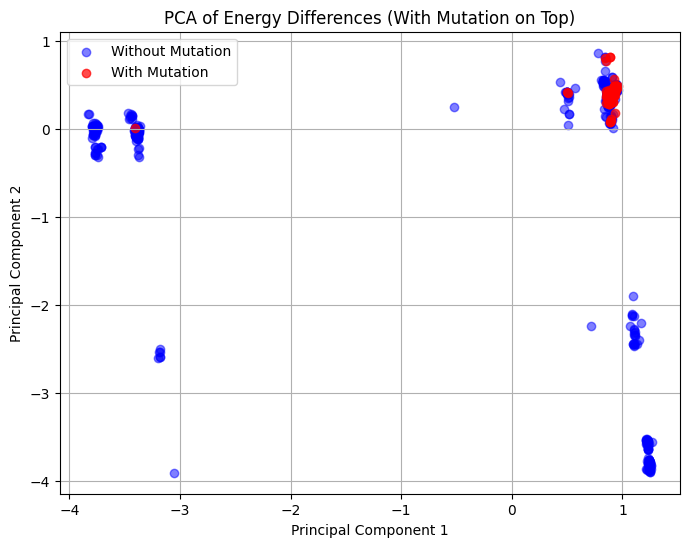

In [14]:


importlib.reload(functions)
importlib.reload(explore)

# Encode sequences with energy differences
def encode_sequences_with_energy_diff(sequences):
    encoded = []
    seq_count = 0
    for seq in sequences:
        seq_encoded = []
        # Calculate the delta E residue for the entire sequence
        for pos in range(1,len(seq)):
            if pos == pos1 or pos == pos2:
                de_residue = 0
            else:
                de_residue = explore.calculate_residue_de12(pos, p1_reduced, p2_reduced, seq, IN_J, 1, 263)
            # print(f"Position {pos + 1}, Sequence: {seq_count}, ΔE_residue: {de_residue}")
            seq_encoded.append(de_residue)

        encoded.append(seq_encoded)
        seq_count += 1
    return np.array(encoded)

# Example usage
wildtype_seq = IN_consensus_seq  # Wildtype sequence
mutant_seq = list(IN_consensus_seq)  # Start with the wildtype
mutant_seq[pos1 - 1] = mt1  # Apply first mutation
mutant_seq[pos2 - 1] = mt2  # Apply second mutation
mutant_seq = ''.join(mutant_seq)

encoded_with_mutation = encode_sequences_with_energy_diff(seq_with_mutation)
encoded_without_mutation = encode_sequences_with_energy_diff(seq_without_mutation)

# Perform PCA on encoded sequences with energy differences
combined_energy_diff = np.vstack((encoded_with_mutation, encoded_without_mutation))

# Run PCA
pca_energy_diff = PCA(n_components=5)
pca_energy_diff.fit(combined_energy_diff)

# Get the top 5 deciding positions based on explained variance
top_deciding_positions_energy_diff = np.argsort(-np.abs(pca_energy_diff.components_).sum(axis=0))[:5]
print("Top 5 deciding positions based on energy differences:", top_deciding_positions_energy_diff + 1)  # Add 1 for 1-based indexing

# Project the sequences onto the first two principal components
pca_transformed_energy_diff = pca_energy_diff.transform(combined_energy_diff)

# Separate the transformed data for sequences with and without mutation
pca_with_mutation_energy_diff = pca_transformed_energy_diff[:len(encoded_with_mutation)]
pca_without_mutation_energy_diff = pca_transformed_energy_diff[len(encoded_with_mutation):]
# Plot the PCA results with mutation on top of without mutation
plt.figure(figsize=(8, 6))
plt.scatter(pca_without_mutation_energy_diff[:, 0], pca_without_mutation_energy_diff[:, 1], 
            color='blue', label='Without Mutation', alpha=0.5)
plt.scatter(pca_with_mutation_energy_diff[:, 0], pca_with_mutation_energy_diff[:, 1], 
            color='red', label='With Mutation', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Energy Differences (With Mutation on Top)')
plt.legend()
plt.grid(True)
plt.show()

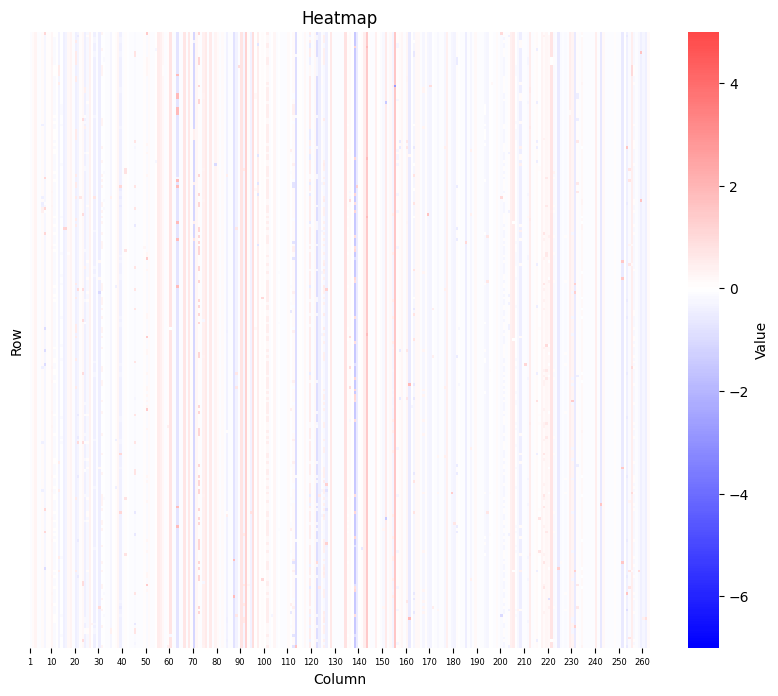

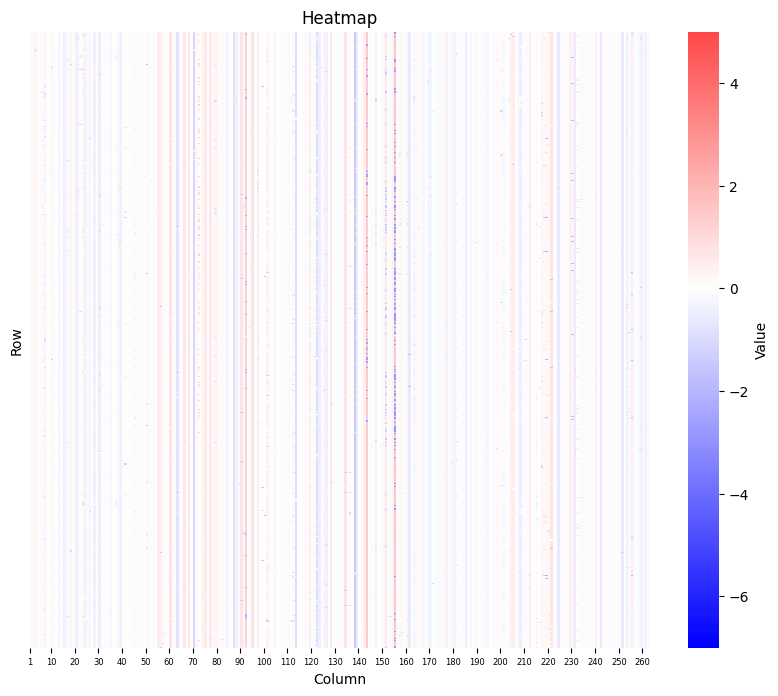

In [11]:
explore.draw_heatmap2(encoded_with_mutation,1,263)
explore.draw_heatmap2(encoded_without_mutation,1,263)

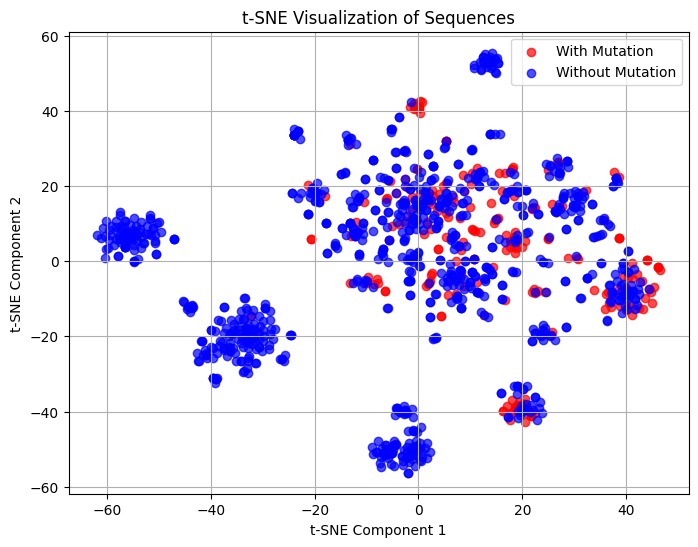

In [17]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

# Combine sequences with and without mutation for clustering
combined_data = np.vstack((encoded_with_mutation, encoded_without_mutation))

# Perform t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
tsne_transformed = tsne.fit_transform(combined_data)

# Separate the transformed data for sequences with and without mutation
tsne_with_mutation = tsne_transformed[:len(encoded_with_mutation)]
tsne_without_mutation = tsne_transformed[len(encoded_with_mutation):]

# Plot the t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_with_mutation[:, 0], tsne_with_mutation[:, 1], color='red', label='With Mutation', alpha=0.7)
plt.scatter(tsne_without_mutation[:, 0], tsne_without_mutation[:, 1], color='blue', label='Without Mutation', alpha=0.7)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Sequences')
plt.legend()
plt.grid(True)
plt.show()